### Import Libraries

In [1]:
import numpy as np
import matplotlib.pyplot as plt

### Create Dataset

We will use a small dataset similar to XOR.

In [2]:
X = np.array([[0,0],
              [0,1],
              [1,0],
              [1,1]])

y = np.array([[0],
              [1],
              [1],
              [0]])

### Define Activation Functions
Sigmoid Function

\sigma(x)=\frac{1}{1+e^{-x}}

In [3]:
def sigmoid(x):
    return 1/(1+np.exp(-x))

### ReLU Function

f(x)=\max(0,x)

In [4]:
def relu(x):
    return np.maximum(0,x)

### Training Function

In [5]:
def train_network(activation):

    np.random.seed(1)

    W1 = np.random.randn(2,3)
    W2 = np.random.randn(3,1)

    losses = []

    for epoch in range(1000):

        # Forward pass
        hidden_input = np.dot(X, W1)

        if activation == "sigmoid":
            hidden_output = sigmoid(hidden_input)
        else:
            hidden_output = relu(hidden_input)

        output_input = np.dot(hidden_output, W2)
        predicted = sigmoid(output_input)

        # Loss
        loss = np.mean((y - predicted)**2)
        losses.append(loss)

        # Simple gradient update
        d_pred = (predicted - y)

        W2 -= 0.01 * np.dot(hidden_output.T, d_pred)
        W1 -= 0.01 * np.dot(X.T, np.dot(d_pred, W2.T))

    return losses

### Train Both Models

In [6]:
loss_sigmoid = train_network("sigmoid")
loss_relu = train_network("relu")

### Compare Training Performance

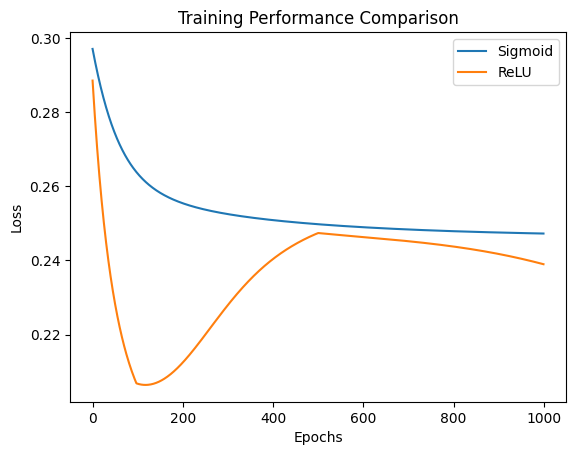

In [7]:
plt.plot(loss_sigmoid, label="Sigmoid")
plt.plot(loss_relu, label="ReLU")

plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title("Training Performance Comparison")

plt.legend()
plt.show()